In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load Data

In [14]:
df = load_breast_cancer(as_frame=True)

In [21]:
X = pd.DataFrame(df.data)
Y = pd.Series(df.target)
data = X.copy()
data['diagnosis'] = Y

In [22]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Preprocessing

In [23]:
correlations = data.corr()['diagnosis'].sort_values(ascending=False)
correlations

diagnosis                  1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

In [27]:
threshold = 0.3

high_corr_features = correlations[
    correlations.abs() > threshold
].index.tolist()

high_corr_features

['diagnosis',
 'worst fractal dimension',
 'mean symmetry',
 'mean smoothness',
 'concave points error',
 'mean texture',
 'worst symmetry',
 'worst smoothness',
 'worst texture',
 'area error',
 'perimeter error',
 'radius error',
 'worst compactness',
 'mean compactness',
 'worst concavity',
 'mean concavity',
 'mean area',
 'mean radius',
 'worst area',
 'mean perimeter',
 'worst radius',
 'mean concave points',
 'worst perimeter',
 'worst concave points']

In [29]:
data = data[high_corr_features]
data.head()

,diagnosis,worst fractal dimension,mean symmetry,mean smoothness,concave points error,mean texture,worst symmetry,worst smoothness,worst texture,area error,...,worst concavity,mean concavity,mean area,mean radius,worst area,mean perimeter,worst radius,mean concave points,worst perimeter,worst concave points
0,0,0.11890,0.2419,0.11840,0.01587,10.38,0.4601,0.1622,17.33,153.40,...,0.7119,0.3001,1001.0,17.99,2019.0,122.80,25.38,0.14710,184.60,0.2654
1,0,0.08902,0.1812,0.08474,0.01340,17.77,0.2750,0.1238,23.41,74.08,...,0.2416,0.0869,1326.0,20.57,1956.0,132.90,24.99,0.07017,158.80,0.1860
2,0,0.08758,0.2069,0.10960,0.02058,21.25,0.3613,0.1444,25.53,94.03,...,0.4504,0.1974,1203.0,19.69,1709.0,130.00,23.57,0.12790,152.50,0.2430
3,0,0.17300,0.2597,0.14250,0.01867,20.38,0.6638,0.2098,26.50,27.23,...,0.6869,0.2414,386.1,11.42,567.7,77.58,14.91,0.10520,98.87,0.2575
4,0,0.07678,0.1809,0.10030,0.01885,14.34,0.2364,0.1374,16.67,94.44,...,0.4000,0.1980,1297.0,20.29,1575.0,135.10,22.54,0.10430,152.20,0.1625


In [32]:
x = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

In [33]:
# split data
x_train , x_test , y_train , y_test = train_test_split(x, y ,test_size=0.2 , random_state=42)

In [34]:
# scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
x_test_scaled

array([[ 0.20372995,  0.41524141,  0.28085007, ..., -0.26486866,
        -0.33154752, -0.19435087],
       [-1.00838949, -0.83398079, -0.40653902, ...,  0.82144876,
         1.76366112,  0.99177862],
       [-0.20629287,  0.43709369,  0.96752014, ...,  0.85722095,
         0.53383214,  0.57035018],
       ...,
       [-0.32408328,  0.26227543,  0.3994894 , ..., -0.49949217,
        -0.78658424, -0.27741059],
       [-0.33137507, -1.70807212, -0.97169365, ..., -0.11046955,
        -0.13807443, -0.49027026],
       [-0.09467243, -0.15291796, -0.07578695, ...,  1.0042552 ,
         3.20646049,  0.7925579 ]])

In [63]:
data.reset_index(drop=True, inplace=True)
data.to_csv('data_cancer.csv', index=False)

# 1. LogisticRegression

In [36]:
LR=LogisticRegression()
LR.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_pred=LR.predict(x_test_scaled)

In [38]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



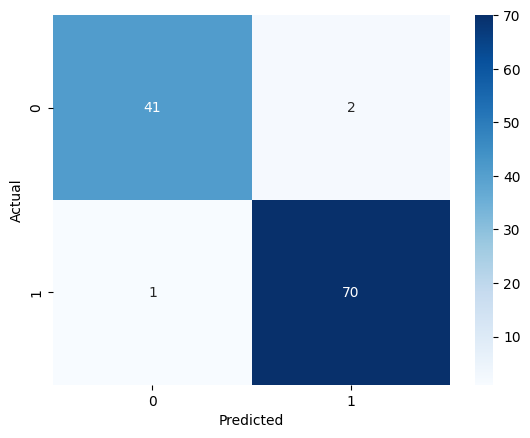

In [39]:
cm =confusion_matrix(y_test, y_pred)
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 2. DecisionTreeClassifier

In [42]:
DT =DecisionTreeClassifier(random_state=42)
param = {
    'min_samples_split' : [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [4, 6, 8],               # عمق الشجرة
}

grid = GridSearchCV(DT, param, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [43]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", - grid.best_score_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.2305964730642222


In [45]:
DT = DecisionTreeClassifier(max_depth=4 ,random_state=42)
DT.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
y_pred_DT = DT.predict(x_test_scaled)

In [52]:
print("Test set accuracy:", accuracy_score(y_test, y_pred_DT))
print("="*50)
print("Classification report:\n", classification_report(y_test, y_pred_DT))

Test set accuracy: 0.9385964912280702
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



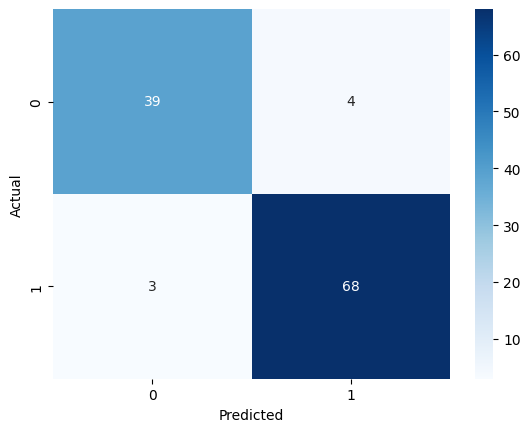

In [51]:
cm =confusion_matrix(y_test, y_pred_DT)
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 3. RandomForestClassifier

In [53]:
RF =RandomForestClassifier(random_state=42)
param = {
    'n_estimators': [100, 200, 300],
    'min_samples_split' : [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [4, 6, 8],
}

grid = GridSearchCV(RF, param, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [55]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", - grid.best_score_)

Best Parameters: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.19946732099692394


In [56]:
# train model
RF = RandomForestClassifier(n_estimators=300, max_depth=6,
                            random_state=42, n_jobs=-1 )

RF.fit(x_train_scaled , y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred_RF = RF.predict(x_test_scaled)

In [58]:
print("Test set accuracy:", accuracy_score(y_test, y_pred_RF))
print("="*50)
print("Classification report:\n", classification_report(y_test, y_pred_RF))

Test set accuracy: 0.9649122807017544
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



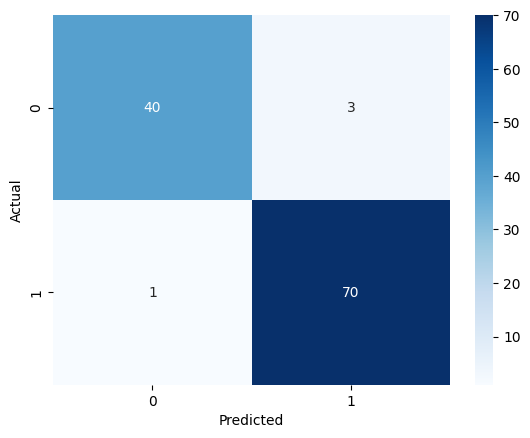

In [59]:
cm =confusion_matrix(y_test, y_pred_RF)
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Performance Comparison

In [60]:
performance = pd.DataFrame(
    {
     'LR': ['0.97', '0.97', '0.97'],
     'DT':  ['0.94', '0.93', '0.94'],
     'RF': ['0.07', '0.96', '0.96']
     },
    index=[['precision', 'recall', 'f1-score']]
)
performance

,LR,DT,RF
precision,0.97,0.94,0.07
recall,0.97,0.93,0.96
f1-score,0.97,0.94,0.96


In [62]:
joblib.dump(LR, 'Breast_Cancer_model.pkl')
joblib.dump(scaler, 'Scaler.pkl')

['Scaler.pkl']